# Improving Adversarial Robustness Against C&W

This notebook trains a ResNet20 model using **TRADES with PGD-10** and **Adversarial Weight Perturbation (AWP)**. The final model is evaluated against the C&W L2 attack.

In [2]:
from pathlib import Path
import os

RUN_ON_DRIVE = False

PROJECT_NAME = "adversarial_attacks_and_defenses"


In [3]:
if RUN_ON_DRIVE:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise RuntimeError(
            "RUN_ON_DRIVE=True requires Google Colab. "
            "Set RUN_ON_DRIVE=False for local execution."
        ) from exc

    DRIVE_MOUNT_DIR = Path("/content/drive")
    drive.mount(
        str(DRIVE_MOUNT_DIR),
        force_remount=False
    )

    PROJECT_DIR = (
        DRIVE_MOUNT_DIR
        / "MyDrive"
        / PROJECT_NAME
    )

else:
    current_dir = Path.cwd().resolve()

    PROJECT_DIR = (
        current_dir
        if current_dir.name == PROJECT_NAME
        else current_dir / PROJECT_NAME
    )

PROJECT_DIR = PROJECT_DIR.resolve()

DATA_DIR = PROJECT_DIR / "data"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
RESULTS_DIR = PROJECT_DIR / "results"
CACHE_DIR = PROJECT_DIR / "cache"

HF_HOME_DIR = CACHE_DIR / "huggingface"
TORCH_HOME_DIR = CACHE_DIR / "torch"

for directory in (
    PROJECT_DIR,
    DATA_DIR,
    CHECKPOINTS_DIR,
    RESULTS_DIR,
    CACHE_DIR,
    HF_HOME_DIR,
    TORCH_HOME_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

os.environ["HF_HOME"] = str(HF_HOME_DIR)
os.environ["HF_HUB_CACHE"] = str(
    HF_HOME_DIR / "hub"
)
os.environ["TORCH_HOME"] = str(
    TORCH_HOME_DIR
)

print(f"RUN_ON_DRIVE  : {RUN_ON_DRIVE}")
print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"DATA_DIR      : {DATA_DIR}")
print(f"CHECKPOINTS   : {CHECKPOINTS_DIR}")
print(f"RESULTS_DIR   : {RESULTS_DIR}")
print(f"HF_HOME       : {os.environ['HF_HOME']}")
print(f"TORCH_HOME    : {os.environ['TORCH_HOME']}")

RUN_ON_DRIVE  : False
PROJECT_DIR   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses
DATA_DIR      : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/data
CHECKPOINTS   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/checkpoints
RESULTS_DIR   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/results
HF_HOME       : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/cache/huggingface
TORCH_HOME    : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/cache/torch


In [4]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [6]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## CIFAR-10 Data Preparation

The training data is divided into training and validation subsets. Data augmentation is applied only during training, while all images remain in the pixel range `[0,1]`.

In [8]:
BATCH_SIZE = 128
NUM_WORKERS = 2

DATA_ROOT = DATA_DIR / "cifar10"
DATA_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

VAL_SIZE = 5000

PIN_MEMORY = torch.cuda.is_available()

print("CIFAR-10 root:", DATA_ROOT)

CIFAR-10 root: /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/data/cifar10


In [9]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

raw_transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_aug_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=train_transform
)

full_train_raw_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=raw_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=raw_transform
)

CIFAR10_CLASSES = full_train_raw_dataset.classes

In [10]:
num_train = len(full_train_raw_dataset)
indices = torch.randperm(
    num_train,
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

val_indices = indices[:VAL_SIZE]
train_indices = indices[VAL_SIZE:]

train_dataset = torch.utils.data.Subset(
    full_train_aug_dataset,
    train_indices
)
val_dataset = torch.utils.data.Subset(
    full_train_raw_dataset,
    val_indices
)
mean_std_dataset = torch.utils.data.Subset(
    full_train_raw_dataset,
    train_indices
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
mean_std_loader = torch.utils.data.DataLoader(
    mean_std_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

## ResNet20 Model

A normalization layer is placed inside the ResNet20 model so that adversarial perturbations can be generated directly in the original pixel space.

$$
x_{\mathrm{norm}}=\frac{x-\mu}{\sigma}
$$

In [11]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        mean = torch.tensor(mean).view(1, 3, 1, 1)
        std = torch.tensor(std).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std

In [12]:
def compute_mean_std(loader):
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    num_pixels = 0

    for images, _ in loader:
        batch_size, channels, height, width = images.shape

        num_pixels += batch_size * height * width

        channels_sum += images.sum(dim=[0, 2, 3])
        channels_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    mean = channels_sum / num_pixels

    std = torch.sqrt(channels_squared_sum / num_pixels - mean ** 2)

    return mean, std

In [13]:
cifar10_mean, cifar10_std = compute_mean_std(mean_std_loader)

cifar10_mean = cifar10_mean.tolist()
cifar10_std = cifar10_std.tolist()

print("Mean:", cifar10_mean)
print("Std:", cifar10_std)

Mean: [0.4913501441478729, 0.4821614623069763, 0.44659730792045593]
Std: [0.24704869091510773, 0.24355383217334747, 0.26168447732925415]


In [14]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + self.shortcut(x)
        out = F.relu(out)

        return out

In [15]:
class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(
            3,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(
            out_channels=16,
            num_blocks=3,
            stride=1
        )

        self.layer2 = self._make_layer(
            out_channels=32,
            num_blocks=3,
            stride=2
        )

        self.layer3 = self._make_layer(
            out_channels=64,
            num_blocks=3,
            stride=2
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []

        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)

        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out

In [16]:
def build_resnet20_model(
    cifar10_mean,
    cifar10_std,
    device,
    num_classes=10
):
    resnet20 = ResNet20(num_classes=num_classes)

    model = nn.Sequential(
        Normalize(cifar10_mean, cifar10_std),
        resnet20
    ).to(device)

    return model

In [17]:
model = build_resnet20_model(
    cifar10_mean=cifar10_mean,
    cifar10_std=cifar10_std,
    device=device,
    num_classes=len(CIFAR10_CLASSES)
)

print(model)

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

## C&W L2 Attack

The C&W attack searches for a small L2 perturbation that changes the predicted class:

$$
\min_{\delta}\|\delta\|_2^2+c\,f(x+\delta)
$$

The tanh transformation keeps the adversarial image inside the valid pixel range.

In [18]:
CW_C = 1.0
CW_KAPPA = 0.0
CW_LEARNING_RATE = 0.01

CW_VAL_STEPS = 100
CW_TEST_STEPS = 100

In [19]:
def atanh(x):
    return 0.5 * torch.log((1 + x) / (1 - x))

In [20]:
def image_to_tanh_space(images, eps=1e-6):
    images = torch.clamp(images, eps, 1 - eps)
    return atanh(2 * images - 1)

In [21]:
def tanh_space_to_image(w):
    return 0.5 * (torch.tanh(w) + 1)

In [22]:
def cw_attack(
    model,
    images,
    labels,
    c,
    kappa,
    num_steps,
    lr,
    device
):
    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    batch_size = images.size(0)

    w = image_to_tanh_space(images).detach()
    w.requires_grad = True

    optimizer = torch.optim.Adam([w], lr=lr)

    best_adv_images = images.clone().detach()

    best_l2 = torch.full(
        (batch_size,),
        float("inf"),
        device=device
    )

    best_success = torch.zeros(
        batch_size,
        dtype=torch.bool,
        device=device
    )

    for step in range(num_steps + 1):
        adv_images = tanh_space_to_image(w)

        logits = model(adv_images)

        one_hot_labels = F.one_hot(
            labels,
            num_classes=logits.size(1)
        ).bool()

        true_logits = logits.gather(
            1,
            labels.view(-1, 1)
        ).squeeze(1)

        wrong_logits = logits.masked_fill(
            one_hot_labels,
            -float("inf")
        )

        max_wrong_logits = wrong_logits.max(dim=1).values

        f_loss = torch.clamp(
            true_logits - max_wrong_logits,
            min=-kappa
        )

        l2_loss_per_sample = torch.sum(
            (adv_images - images) ** 2,
            dim=[1, 2, 3]
        )

        with torch.no_grad():
            preds = logits.argmax(dim=1)
            success = preds != labels

            improved = (
                success
                & (l2_loss_per_sample < best_l2)
            )

            best_l2[improved] = l2_loss_per_sample[improved]

            best_adv_images[improved] = (
                adv_images[improved].detach()
            )

            best_success[improved] = True

        if step == num_steps:
            break

        loss = l2_loss_per_sample + c * f_loss
        loss = loss.sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    final_adv_images = best_adv_images.detach().clone()

    with torch.no_grad():
        final_logits = model(final_adv_images)
        final_preds = final_logits.argmax(dim=1)

    return (
        final_adv_images,
        best_success,
        best_l2,
        final_preds
    )

## TRADES Adversarial Training

TRADES balances clean accuracy and adversarial robustness by combining the natural classification loss with a robustness term:

$$
L_{\mathrm{TRADES}}
=
L_{\mathrm{CE}}(f(x),y)
+
\beta\,
D_{\mathrm{KL}}
\left(
f(x)\,\|\,f(x_{\mathrm{adv}})
\right)
$$

The adversarial samples are generated using 10-step PGD.

In [23]:
TRADES_EPSILON = 0.031
TRADES_STEP_SIZE = 0.007
TRADES_PERTURB_STEPS = 10

## Adversarial Weight Perturbation

AWP temporarily perturbs the model weights toward a direction that increases the TRADES loss. The model is then optimized at the perturbed weights before the perturbation is removed.

In [24]:
AWP_GAMMA = 5e-3
AWP_WARMUP_EPOCHS = 10
AWP_NUM_STEPS = 1
AWP_PROXY_LR = 0.1

AWP_EPS = 1e-20

In [25]:
def diff_in_weights(
    model,
    proxy_model,
    eps=AWP_EPS
):

    model_parameters = dict(
        model.named_parameters()
    )

    proxy_parameters = dict(
        proxy_model.named_parameters()
    )

    weight_diff = {}

    for name, model_weight in model_parameters.items():
        if name not in proxy_parameters:
            raise KeyError(
                f"Parameter {name!r} was not found "
                "in the proxy model."
            )

        if model_weight.ndim <= 1:
            continue

        if "weight" not in name:
            continue

        proxy_weight = proxy_parameters[name]

        raw_difference = (
            proxy_weight.detach()
            - model_weight.detach()
        )

        normalized_difference = (
            model_weight.detach().norm()
            / (
                raw_difference.norm()
                + eps
            )
        ) * raw_difference

        weight_diff[name] = normalized_difference

    return weight_diff

In [26]:
def add_into_weights(
    model,
    weight_diff,
    coefficient=1.0
):

    model_parameters = dict(
        model.named_parameters()
    )

    with torch.no_grad():
        for name, difference in weight_diff.items():
            if name not in model_parameters:
                raise KeyError(
                    f"Parameter {name!r} was not found "
                    "in the model."
                )

            model_parameters[name].add_(
                coefficient * difference
            )

In [27]:
class TradesAWP:
    
    def __init__(
        self,
        model,
        proxy_model,
        proxy_optimizer,
        gamma,
        num_steps=1
    ):
        self.model = model
        self.proxy_model = proxy_model
        self.proxy_optimizer = proxy_optimizer
        self.gamma = gamma
        self.num_steps = num_steps

    def calculate(
        self,
        clean_images,
        adversarial_images,
        labels,
        beta
    ):
        clean_images = clean_images.detach()
        adversarial_images = adversarial_images.detach()
        labels = labels.detach()

        self.proxy_model.load_state_dict(
            self.model.state_dict()
        )

        self.proxy_model.train()

        for _ in range(self.num_steps):
            clean_logits = self.proxy_model(
                clean_images
            )

            adversarial_logits = self.proxy_model(
                adversarial_images
            )

            natural_loss = F.cross_entropy(
                clean_logits,
                labels
            )

            robust_loss = F.kl_div(
                F.log_softmax(
                    adversarial_logits,
                    dim=1
                ),
                F.softmax(
                    clean_logits,
                    dim=1
                ),
                reduction="batchmean"
            )

            trades_proxy_loss = (
                natural_loss
                + beta * robust_loss
            )

            weight_maximization_loss = (
                -trades_proxy_loss
            )

            self.proxy_optimizer.zero_grad(
                set_to_none=True
            )

            weight_maximization_loss.backward()

            self.proxy_optimizer.step()

        return diff_in_weights(
            model=self.model,
            proxy_model=self.proxy_model
        )

    def perturb(self, weight_diff):
 
        add_into_weights(
            model=self.model,
            weight_diff=weight_diff,
            coefficient=self.gamma
        )

    def restore(self, weight_diff):

        add_into_weights(
            model=self.model,
            weight_diff=weight_diff,
            coefficient=-self.gamma
        )

In [28]:
def generate_trades_adversarial_examples(
    model,
    x_natural,
    step_size,
    epsilon,
    perturb_steps
):
    previous_training_state = model.training
    model.eval()

    x_natural = x_natural.detach()

    with torch.no_grad():
        clean_probabilities = F.softmax(
            model(x_natural),
            dim=1
        )

    x_adv = (
        x_natural
        + 0.001 * torch.randn_like(x_natural)
    )

    x_adv = torch.clamp(
        x_adv,
        min=0.0,
        max=1.0
    )

    for _ in range(perturb_steps):
        x_adv.requires_grad_(True)

        adversarial_logits = model(x_adv)

        inner_kl_loss = F.kl_div(
            F.log_softmax(
                adversarial_logits,
                dim=1
            ),
            clean_probabilities,
            reduction="batchmean"
        )

        input_gradient = torch.autograd.grad(
            outputs=inner_kl_loss,
            inputs=x_adv,
            only_inputs=True
        )[0]

        x_adv = (
            x_adv.detach()
            + step_size * input_gradient.sign()
        )

        perturbation = torch.clamp(
            x_adv - x_natural,
            min=-epsilon,
            max=epsilon
        )

        x_adv = torch.clamp(
            x_natural + perturbation,
            min=0.0,
            max=1.0
        )

    if previous_training_state:
        model.train()
    else:
        model.eval()

    return x_adv.detach()


In [29]:
def compute_trades_loss(
    model,
    x_natural,
    x_adversarial,
    labels,
    beta
):

    clean_logits = model(x_natural)

    adversarial_logits = model(
        x_adversarial.detach()
    )

    natural_loss = F.cross_entropy(
        clean_logits,
        labels
    )

    robust_loss = F.kl_div(
        F.log_softmax(
            adversarial_logits,
            dim=1
        ),
        F.softmax(
            clean_logits,
            dim=1
        ),
        reduction="batchmean"
    )

    total_loss = (
        natural_loss
        + beta * robust_loss
    )

    return total_loss, clean_logits


In [30]:
def trades_loss(
    model,
    x_natural,
    labels,
    step_size,
    epsilon,
    perturb_steps,
    beta
):

    x_adversarial = generate_trades_adversarial_examples(
        model=model,
        x_natural=x_natural,
        step_size=step_size,
        epsilon=epsilon,
        perturb_steps=perturb_steps
    )

    model.train()

    total_loss, clean_logits = compute_trades_loss(
        model=model,
        x_natural=x_natural,
        x_adversarial=x_adversarial,
        labels=labels,
        beta=beta
    )

    return (
        total_loss,
        clean_logits,
        x_adversarial
    )

In [31]:
def train_trades_epoch(
    model,
    loader,
    optimizer,
    beta,
    device,
    epoch_number,
    awp_adversary=None,
    awp_warmup_epochs=0
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    use_awp = (
        awp_adversary is not None
        and epoch_number >= awp_warmup_epochs
    )

    for images, labels in loader:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        x_adversarial = (
            generate_trades_adversarial_examples(
                model=model,
                x_natural=images,
                step_size=TRADES_STEP_SIZE,
                epsilon=TRADES_EPSILON,
                perturb_steps=TRADES_PERTURB_STEPS
            )
        )

        model.train()

        weight_diff = None

        if use_awp:
            weight_diff = awp_adversary.calculate(
                clean_images=images,
                adversarial_images=x_adversarial,
                labels=labels,
                beta=beta
            )

        optimizer.zero_grad(
            set_to_none=True
        )

        if use_awp:
            awp_adversary.perturb(
                weight_diff=weight_diff
            )

        try:
            loss, clean_logits = compute_trades_loss(
                model=model,
                x_natural=images,
                x_adversarial=x_adversarial,
                labels=labels,
                beta=beta
            )

            loss.backward()

            optimizer.step()

        finally:

            if use_awp:
                awp_adversary.restore(
                    weight_diff=weight_diff
                )

        batch_size = labels.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        predictions = clean_logits.argmax(
            dim=1
        )

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    if total_samples == 0:
        raise RuntimeError(
            "The training loader contained no samples."
        )

    average_loss = (
        total_loss / total_samples
    )

    average_accuracy = (
        total_correct / total_samples
    )

    return (
        average_loss,
        average_accuracy,
        use_awp
    )

## PGD Sanity Check

This test verifies that the generated adversarial images remain inside `[0,1]` and satisfy the specified L-infinity perturbation budget.

In [32]:
# Sanity Check
sample_images, sample_labels = next(
    iter(train_loader)
)

sample_images = sample_images.to(
    device,
    non_blocking=True
)

sample_adversarial = (
    generate_trades_adversarial_examples(
        model=model,
        x_natural=sample_images,
        step_size=TRADES_STEP_SIZE,
        epsilon=TRADES_EPSILON,
        perturb_steps=TRADES_PERTURB_STEPS
    )
)

maximum_linf_distance = (
    sample_adversarial - sample_images
).abs().amax().item()

print(
    "Adversarial batch shape:",
    sample_adversarial.shape
)

print(
    "Maximum L-inf perturbation:",
    maximum_linf_distance
)

assert sample_adversarial.min().item() >= 0.0
assert sample_adversarial.max().item() <= 1.0

assert (
    maximum_linf_distance
    <= TRADES_EPSILON + 1e-6
)

print("TRADES PGD-10 generation test passed.")

Adversarial batch shape: torch.Size([128, 3, 32, 32])
Maximum L-inf perturbation: 0.03100001811981201
TRADES PGD-10 generation test passed.


## Evaluation Functions

Clean accuracy is measured on normal images, while robust accuracy is measured after applying the C&W L2 attack.

In [33]:
@torch.no_grad()
def evaluate_clean(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [34]:
def evaluate_cw_robust(
    model,
    loader,
    device,
    num_steps,
    eval_batches=None
):

    model.eval()

    total_correct = 0
    total_samples = 0

    for batch_index, (images, labels) in enumerate(loader):
        if (
            eval_batches is not None
            and batch_index >= eval_batches
        ):
            break

        adv_images, _, _, _ = cw_attack(
            model=model,
            images=images,
            labels=labels,
            c=CW_C,
            kappa=CW_KAPPA,
            num_steps=num_steps,
            lr=CW_LEARNING_RATE,
            device=device
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        with torch.no_grad():
            logits = model(adv_images)
            predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    if total_samples == 0:
        raise RuntimeError(
            "No samples were evaluated."
        )

    return total_correct / total_samples

## TRADES-AWP Training

The model is trained with SGD and a multi-step learning-rate schedule. The checkpoint with the highest validation accuracy against C&W is saved.

In [35]:
EPOCHS = 30
LR = 0.1
BETA = 6.0

SAVE_PATH = (
    CHECKPOINTS_DIR
    / "resnet20_cifar10_trades_awp.pth"
)

HISTORY_PATH = (
    RESULTS_DIR
    / "resnet20_cifar10_trades_awp_history.pth"
)

model_exists = SAVE_PATH.exists()

print(
    f"AWP checkpoint path: {SAVE_PATH}"
)

print(
    f"Training history path: {HISTORY_PATH}"
)

print(
    f"Existing AWP checkpoint: {model_exists}"
)

AWP checkpoint path: /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/checkpoints/resnet20_cifar10_trades_awp.pth
Training history path: /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/results/resnet20_cifar10_trades_awp_history.pth
Existing AWP checkpoint: True


In [36]:
if model_exists:
    checkpoint_state = torch.load(
        SAVE_PATH,
        map_location=device
    )

    model.load_state_dict(
        checkpoint_state
    )

    model = model.to(device)
    model.eval()

    print(
        f"Loaded existing TRADES-AWP model "
        f"from: {SAVE_PATH}"
    )

else:
    print(
        "No TRADES-AWP checkpoint was found. "
        "Training will start from scratch."
    )

Loaded existing TRADES-AWP model from: /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/checkpoints/resnet20_cifar10_trades_awp.pth


In [37]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[15, 25],
    gamma=0.1
)

In [38]:
if not model_exists:
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_clean_acc": [],
        "val_robust_acc": [],
        "awp_active": []
    }

    best_robust_acc = -float("inf")
    best_epoch = None

    proxy_model = copy.deepcopy(
        model
    ).to(device)

    proxy_optimizer = torch.optim.SGD(
        proxy_model.parameters(),
        lr=AWP_PROXY_LR
    )

    awp_adversary = TradesAWP(
        model=model,
        proxy_model=proxy_model,
        proxy_optimizer=proxy_optimizer,
        gamma=AWP_GAMMA,
        num_steps=AWP_NUM_STEPS
    )

    print(
        f"AWP configuration | "
        f"gamma={AWP_GAMMA} | "
        f"steps={AWP_NUM_STEPS} | "
        f"first AWP epoch="
        f"{AWP_WARMUP_EPOCHS}"
    )

    for epoch in range(EPOCHS):
        epoch_number = epoch + 1
        start_time = time.time()

        current_lr = (
            optimizer.param_groups[0]["lr"]
        )

        (
            train_loss,
            train_acc,
            awp_active
        ) = train_trades_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            beta=BETA,
            device=device,
            epoch_number=epoch_number,
            awp_adversary=awp_adversary,
            awp_warmup_epochs=(
                AWP_WARMUP_EPOCHS
            )
        )

        val_loss, val_clean_acc = (
            evaluate_clean(
                model=model,
                loader=val_loader,
                criterion=criterion,
                device=device
            )
        )

        val_robust_acc = (
            evaluate_cw_robust(
                model=model,
                loader=val_loader,
                device=device,
                num_steps=CW_VAL_STEPS,
                eval_batches=5
            )
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_clean_acc"].append(
            val_clean_acc
        )

        history["val_robust_acc"].append(
            val_robust_acc
        )

        history["awp_active"].append(
            awp_active
        )

        if val_robust_acc > best_robust_acc:
            best_robust_acc = (
                val_robust_acc
            )

            best_epoch = epoch_number

            torch.save(
                model.state_dict(),
                SAVE_PATH
            )

            print(
                f"Saved new best checkpoint "
                f"at epoch {best_epoch}."
            )

        torch.save(
            {
                "history": history,
                "best_epoch": best_epoch,
                "best_robust_acc": (
                    best_robust_acc
                ),
                "completed_epoch": (
                    epoch_number
                ),
                "awp_gamma": AWP_GAMMA,
                "awp_warmup_epochs": (
                    AWP_WARMUP_EPOCHS
                )
            },
            HISTORY_PATH
        )

        scheduler.step()

        elapsed = (
            time.time() - start_time
        )

        print(
            f"Epoch "
            f"[{epoch_number:02d}/{EPOCHS}] | "
            f"Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Clean: {val_clean_acc:.4f} | "
            f"Val C&W: {val_robust_acc:.4f} | "
            f"AWP: "
            f"{'ON' if awp_active else 'OFF'} | "
            f"LR: {current_lr:.6f} | "
            f"Time: {elapsed:.1f}s"
        )

    print(
        f"Training complete | "
        f"Best epoch: {best_epoch} | "
        f"Best validation C&W accuracy: "
        f"{best_robust_acc:.4f}"
    )

else:
    print(
        "Training skipped because a saved "
        "TRADES-AWP checkpoint already exists."
    )

Training skipped because a saved TRADES-AWP checkpoint already exists.


## Training History

Clean and robust validation accuracies are plotted across epochs to identify the best checkpoint and possible robust overfitting.

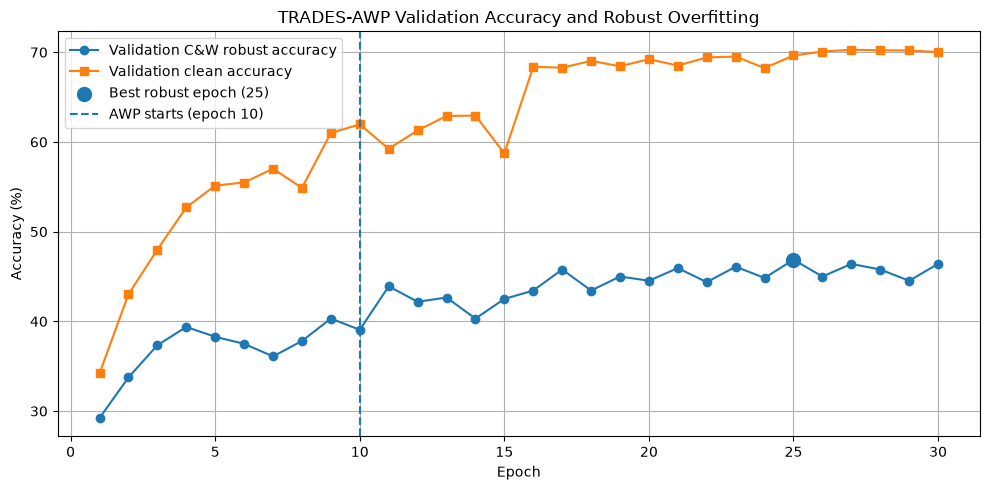

Best robust epoch: 25
Best validation C&W accuracy: 0.4688
Last validation C&W accuracy: 0.4641
Drop after best epoch: 0.47 percentage points


In [39]:
if HISTORY_PATH.exists():
    saved_history_data = torch.load(
        HISTORY_PATH,
        map_location="cpu"
    )

    plot_history = (
        saved_history_data["history"]
    )

elif (
    "history" in globals()
    and len(
        history["val_robust_acc"]
    ) > 0
):
    plot_history = history

else:
    raise FileNotFoundError(
        f"Training history was not found: "
        f"{HISTORY_PATH}"
    )


val_robust_history = np.asarray(
    plot_history["val_robust_acc"],
    dtype=float
)

val_clean_history = np.asarray(
    plot_history["val_clean_acc"],
    dtype=float
)

awp_active_history = np.asarray(
    plot_history["awp_active"],
    dtype=bool
)

if len(val_robust_history) == 0:
    raise RuntimeError(
        "Validation robustness history is empty."
    )

if (
    len(val_clean_history)
    != len(val_robust_history)
):
    raise RuntimeError(
        "Clean and robust history lengths "
        "do not match."
    )

epochs = np.arange(
    1,
    len(val_robust_history) + 1
)

best_index = int(
    np.argmax(val_robust_history)
)

best_epoch_from_history = (
    best_index + 1
)

best_robust_accuracy = (
    val_robust_history[best_index]
)

last_robust_accuracy = (
    val_robust_history[-1]
)

robust_accuracy_drop = (
    best_robust_accuracy
    - last_robust_accuracy
)

active_awp_indices = np.flatnonzero(
    awp_active_history
)

if len(active_awp_indices) > 0:
    awp_start_epoch = (
        int(active_awp_indices[0]) + 1
    )
else:
    awp_start_epoch = None


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs,
    val_robust_history * 100,
    marker="o",
    label=(
        "Validation C&W robust accuracy"
    )
)

plt.plot(
    epochs,
    val_clean_history * 100,
    marker="s",
    label=(
        "Validation clean accuracy"
    )
)

plt.scatter(
    best_epoch_from_history,
    best_robust_accuracy * 100,
    s=100,
    zorder=5,
    label=(
        f"Best robust epoch "
        f"({best_epoch_from_history})"
    )
)

if awp_start_epoch is not None:
    plt.axvline(
        awp_start_epoch,
        linestyle="--",
        label=(
            f"AWP starts "
            f"(epoch {awp_start_epoch})"
        )
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "TRADES-AWP Validation Accuracy "
    "and Robust Overfitting"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


print(
    f"Best robust epoch: "
    f"{best_epoch_from_history}"
)

print(
    f"Best validation C&W accuracy: "
    f"{best_robust_accuracy:.4f}"
)

print(
    f"Last validation C&W accuracy: "
    f"{last_robust_accuracy:.4f}"
)

print(
    f"Drop after best epoch: "
    f"{robust_accuracy_drop * 100:.2f} "
    f"percentage points"
)

## Final Evaluation

The best saved checkpoint is loaded and evaluated on the CIFAR-10 test set using both clean images and the C&W L2 attack.

In [41]:
if not SAVE_PATH.exists():
    raise FileNotFoundError(
        f"Best TRADES-AWP checkpoint "
        f"was not found: {SAVE_PATH}"
    )

best_checkpoint_state = torch.load(
    SAVE_PATH,
    map_location=device
)

model.load_state_dict(
    best_checkpoint_state
)

model = model.to(device)
model.eval()

print(
    f"Loaded best TRADES-AWP model "
    f"from: {SAVE_PATH}"
)

Loaded best TRADES-AWP model from: /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/checkpoints/resnet20_cifar10_trades_awp.pth


In [42]:
# Clean accuracy on the full CIFAR-10 test set.
test_loss, test_clean_acc = (
    evaluate_clean(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device
    )
)

print(
    f"Final Test Clean Accuracy: "
    f"{test_clean_acc:.4f}"
)

print(
    "Running C&W L2 evaluation "
    "on the full test set..."
)

# Competitive C&W L2 evaluation on all test images.
test_robust_acc = evaluate_cw_robust(
    model=model,
    loader=test_loader,
    device=device,
    num_steps=CW_TEST_STEPS,
    eval_batches=None
)

print(
    f"Final Test C&W Robust Accuracy: "
    f"{test_robust_acc:.4f}"
)

Final Test Clean Accuracy: 0.6890
Running C&W L2 evaluation on the full test set...
Final Test C&W Robust Accuracy: 0.4485
